# Student Info
## Name: Jia Changyu
## English Name: Iris
## ID: C00292876

<a class="anchor" id="0.1"></a>
# **Table of Contents**


1.	[Introduction](#1)
2.	[Initial Exploration](#2)
3.	[Processing Data](#3)
4.	[Feature Engineering](#4)
5.	[Model training](#5)
6.	[Conclusion](#6)
7.	[Reference](#7)

# 1. Introduction <a class="anchor" id="1"></a>
[Table of Contents](#0.1)

This project, based on the Kaggle open-source wine quality dataset (1599 samples, 11 physicochemical features), systematically applies and compares three classic machine learning methods:

- K-Nearest Neighbors (K-NN): Performance is evaluated using 5-fold cross-validation for K values ​​ranging from 1 to 19.

- K-means clustering and K-centroid clustering: The elbow rule (WCSS) and silhouette coefficient method are used to select the number of clusters, respectively.

- Support Vector Machine (SVM): Hyperparameters are fine-tuned for the RBF kernel and linear kernel using grid search cross-validation.

The target variable "quality" (original rating range 3-8) is binarized: premium wines (quality ≥ 6, label = 1) and ordinary wines (quality < 6, label = 0), resulting in a nearly balanced binary problem (855 premium wine samples and 744 ordinary wine samples).

**Technology & Dataset Choices:**
- **Python / scikit-learn:** Industry-standard library with consistent API across all algorithms, enabling direct performance comparison under identical preprocessing conditions.
- **Red Wine Quality dataset:** Chosen for its all-numeric features (no encoding overhead), absence of missing values, and natural suitability for both classification and clustering tasks.
- **Algorithm selection rationale:** K-NN and SVM represent distance-based and margin-based supervised approaches respectively, allowing comparison of fundamentally different decision strategies. K-Means and K-Medoids provide unsupervised perspective to discover natural groupings independent of the quality label.


**Load Python modules:** It is used for loading the data analysis module.I have also added some useful auxiliary modules for the project.

In [118]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import category_encoders as ce
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from typing import Tuple, Any
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, LeaveOneOut
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, silhouette_score, calinski_harabasz_score, auc, ConfusionMatrixDisplay
from sklearn.mixture import GaussianMixture
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

import os


In [119]:
winequality_data = pd.read_csv("../data/winequality-red.csv")

# 2. Initial Exploration <a class="anchor" id="2"></a>
[Table of Contents](#0.1)

The dataset contains 1,599 red wine samples with 12 columns — 11 continuous physicochemical input features and 1 integer quality score. We examine shape, statistical summary, and data types to understand scale and completeness before preprocessing.

In [120]:
winequality_data.shape

(1599, 12)

The summary statistics reveal large scale differences across features: total sulfur dioxide ranges from 6 to 289, while pH only spans 2.74–4.01. This motivates the use of StandardScaler before distance-based models (K-NN, SVM). The mean quality score is 5.64, confirming most wines are of moderate quality.

In [121]:
winequality_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


All 1,599 rows are complete with no missing values across all 12 columns. All input features are float64 and the target quality is int64 — no imputation or type conversion is needed before modeling.

In [122]:
winequality_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


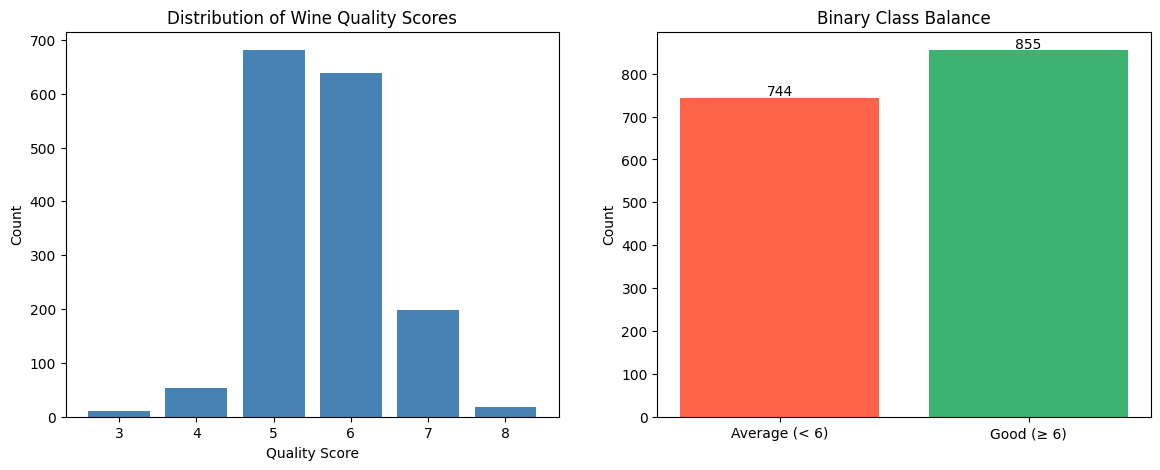

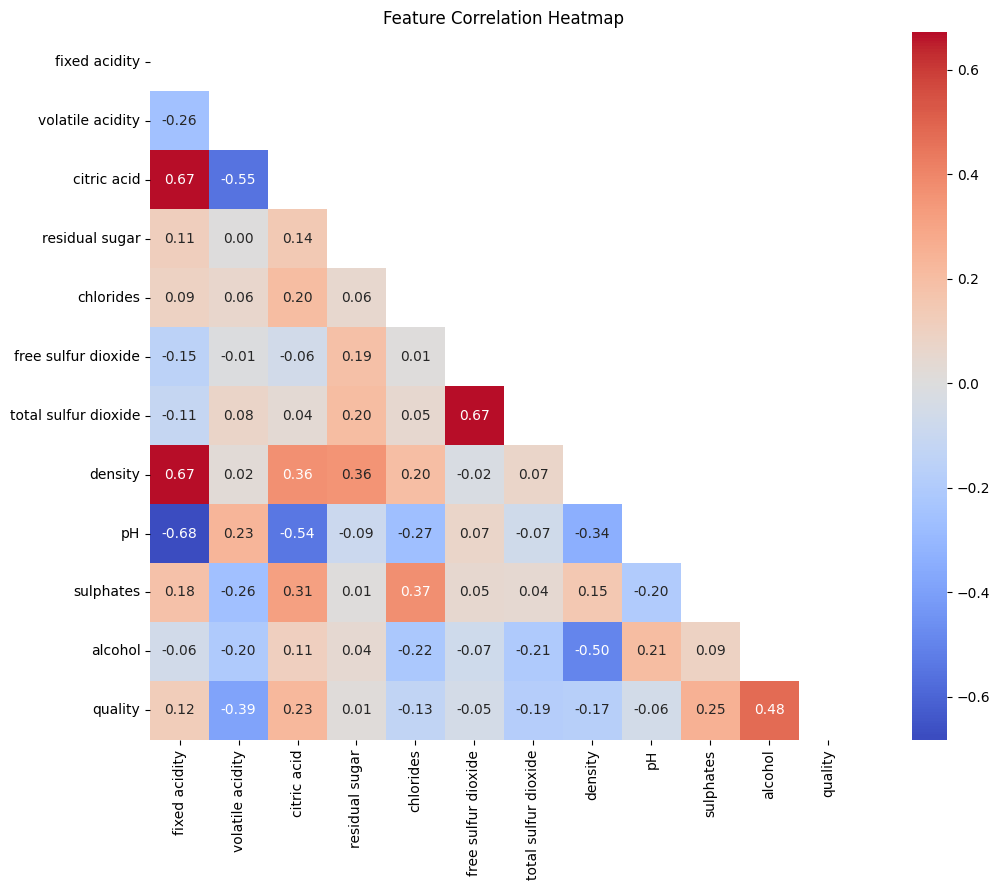

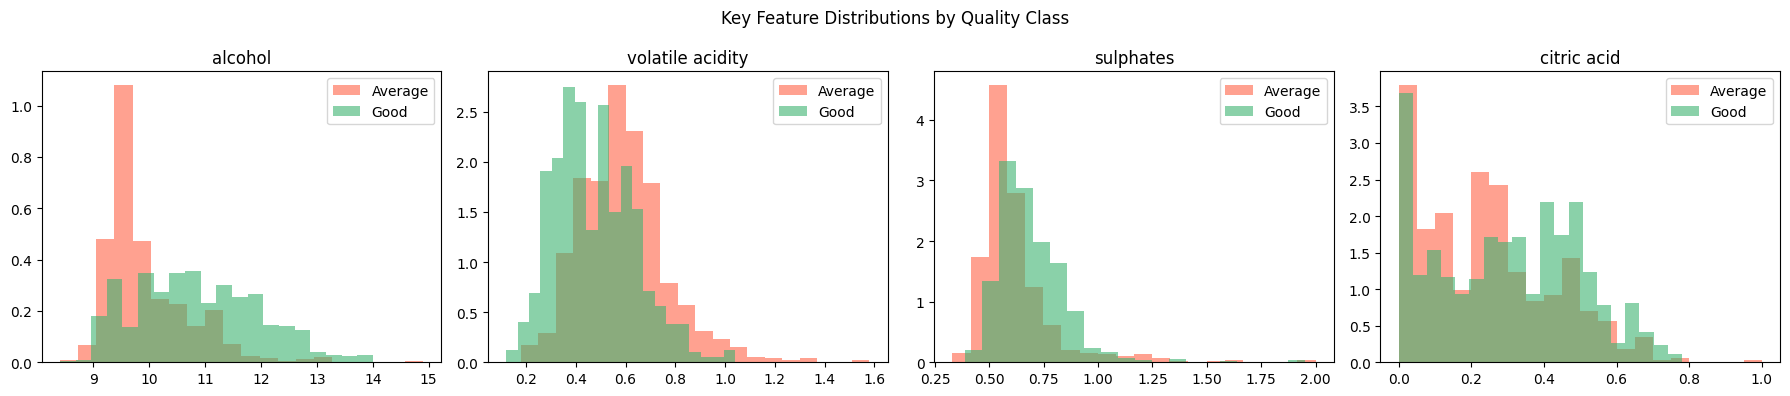

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quality score distribution
quality_counts = winequality_data['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue')
axes[0].set_title('Distribution of Wine Quality Scores')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')

# Binary class balance
binary_counts = [744, 855]
axes[1].bar(['Average (< 6)', 'Good (≥ 6)'], binary_counts, color=['tomato', 'mediumseagreen'])
axes[1].set_title('Binary Class Balance')
axes[1].set_ylabel('Count')
for i, v in enumerate(binary_counts):
    axes[1].text(i, v + 5, str(v), ha='center')

# Feature correlation heatmap
plt.figure(figsize=(12, 9))
corr = winequality_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Key feature distributions by quality class
features_to_plot = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Key Feature Distributions by Quality Class')
for ax, feat in zip(axes, features_to_plot):
    ax.hist(winequality_data[winequality_data['quality'] < 6][feat], bins=20, alpha=0.6, color='tomato', label='Average', density=True)
    ax.hist(winequality_data[winequality_data['quality'] >= 6][feat], bins=20, alpha=0.6, color='mediumseagreen', label='Good', density=True)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

**Key EDA findings:**
- Quality scores are concentrated at 5 and 6 (>80% of samples), with very few wines rated 3 or 8.
- After binarization, classes are near-balanced (744 average vs. 855 good) — no resampling required.
- The correlation heatmap shows alcohol has the strongest positive correlation with quality (+0.48), and volatile acidity the strongest negative correlation (−0.39).
- Feature distribution plots confirm: good wines tend to have higher alcohol and sulphates, and lower volatile acidity — these will be the most informative features for classifiers.

# 3. Processing Data <a class="anchor" id="3"></a>
[Table of Contents](#0.1)

## Declare feature vector and target variable

Create the feature matrix X by dropping the quality and quality_binary columns, and define the binary target vector y from quality_binary (1 = good wine, 0 = average wine).

In [124]:
# Convert the multi-classification problem to a binary classification: If quality is greater than or equal to 6, it is classified as 1 (good wine); otherwise, it is classified as 0 (average wine).
winequality_data['quality_binary'] = (winequality_data['quality'] >= 6).astype(int)
print(winequality_data['quality_binary'].value_counts())

X = winequality_data.drop(['quality', 'quality_binary'], axis=1)
y = winequality_data['quality_binary']


quality_binary
1    855
0    744
Name: count, dtype: int64


Split the features (X) and target (y) into training and testing sets (70% train, 30% test) with a fixed random seed for reproducibility.

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

Display the dimensions (number of rows and columns) of the training and testing feature sets to verify the split.

In [126]:
X_train.shape, X_test.shape

((1119, 11), (480, 11))

Checks and displays the data types of each column in the X_train DataFrame.

In [127]:
X_train.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object

# 4. Feature Engineering <a class="anchor" id="4"></a>
[Table of Contents](#0.1)

## 4.1. Data Classification 

Create a list of column names where the data type is 'Object'. Then, print the total number of categorical variables found in the dataset and the names of the categorical variables stored in the list.

In [128]:
numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']
print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are :\n\n', numerical)

There are 11 numerical variables

The numerical variables are :

 ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


Starts a loop to iterate through each variable name in the categorical list. For each categorical variable, prints its name and the number of unique categories it contains.

In [129]:
for var in categorical:
    print(var, ' contains ', len(winequality_data[var].unique()), ' labels')

Create a list of column names in X_train where the data type is NOT 'Object' (i.e., numerical).

In [130]:
numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']
print('There are {} categorical variables\n'.format(len(numerical)))
print('The categorical variables are :\n\n', numerical)

There are 11 categorical variables

The categorical variables are :

 ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## 4.2. Feature Scaling

All features are standardized using StandardScaler (zero mean, unit variance). This step is critical for K-NN and SVM, which are both sensitive to feature scale. The scaled version is used for clustering as well to prevent high-range features (e.g., total sulfur dioxide) from dominating distance calculations.

In [131]:
features = winequality_data.drop('quality', axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

## 4.3. Encode 

Encode categorical variables

Since the wine quality dataset contains no categorical variables (confirmed in Section 4.1), the OneHotEncoder is applied with an empty column list and has no effect. All features remain in their original numerical form.

In [132]:
encoder = ce.OneHotEncoder(cols=categorical)
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

Apply StandardScaler to normalize all features. The scaler is fitted on training data only and applied (transformed) to both training and test sets to prevent data leakage.

In [133]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model training <a class="anchor" id="5"></a>
[Table of Contents](#0.1)

### 5.1. k-Nearest Neighbour

In [134]:
print("\n" + "="*50)
print("K-NN Model Comparison Experiment")
print("="*50)

k_values = range(1, 21, 2)
train_scores = []
test_scores = []
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train_scaled, y_train)
    train_pred = knn.predict(X_train_scaled)
    train_scores.append(accuracy_score(y_train, train_pred))
    
    test_pred = knn.predict(X_test_scaled)
    test_scores.append(accuracy_score(y_test, test_pred))
    
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    cv_scores.append(cv_score)
    
    print(f"K={k:2d} | Training accuracy: {train_scores[-1]:.4f} | Testing accuracy: {test_scores[-1]:.4f} | Cross validation: {cv_scores[-1]:.4f}")



K-NN Model Comparison Experiment
K= 1 | Training accuracy: 1.0000 | Testing accuracy: 0.7125 | Cross validation: 0.7418
K= 3 | Training accuracy: 0.8677 | Testing accuracy: 0.6813 | Cross validation: 0.7274
K= 5 | Training accuracy: 0.8248 | Testing accuracy: 0.6854 | Cross validation: 0.7283
K= 7 | Training accuracy: 0.8114 | Testing accuracy: 0.6771 | Cross validation: 0.7310


K= 9 | Training accuracy: 0.7900 | Testing accuracy: 0.6729 | Cross validation: 0.7328
K=11 | Training accuracy: 0.7909 | Testing accuracy: 0.6875 | Cross validation: 0.7354
K=13 | Training accuracy: 0.7864 | Testing accuracy: 0.6937 | Cross validation: 0.7381
K=15 | Training accuracy: 0.7819 | Testing accuracy: 0.7000 | Cross validation: 0.7328
K=17 | Training accuracy: 0.7784 | Testing accuracy: 0.6896 | Cross validation: 0.7301
K=19 | Training accuracy: 0.7703 | Testing accuracy: 0.6979 | Cross validation: 0.7292


In [135]:
def evaluate_classifier(model, X_test, y_test, model_name="Model"):
    """
    Evaluate a trained classifier on the test set.
    Prints accuracy and full classification report.
    Returns predictions.
    """
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Average', 'Good']))
    return y_pred


def plot_confusion_matrix(y_test, y_pred, title="Confusion Matrix", ax=None):
    """
    Plot a labeled confusion matrix heatmap.
    If ax is provided, draws on that axis (for subplots).
    """
    cm = confusion_matrix(y_test, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Average', 'Good'],
                yticklabels=['Average', 'Good'])
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)


def plot_roc_curve(model, X_test, y_test, ax=None):
    """
    Plot the ROC curve and return AUC score.
    Requires model to support predict_proba.
    """
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    return roc_auc


def get_silhouette_scores(data, k_range):
    """
    Compute silhouette scores for K-Means across a range of k values.
    Returns list of scores.
    """
    scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42)
        labels = km.fit_predict(data)
        scores.append(silhouette_score(data, labels))
    return scores

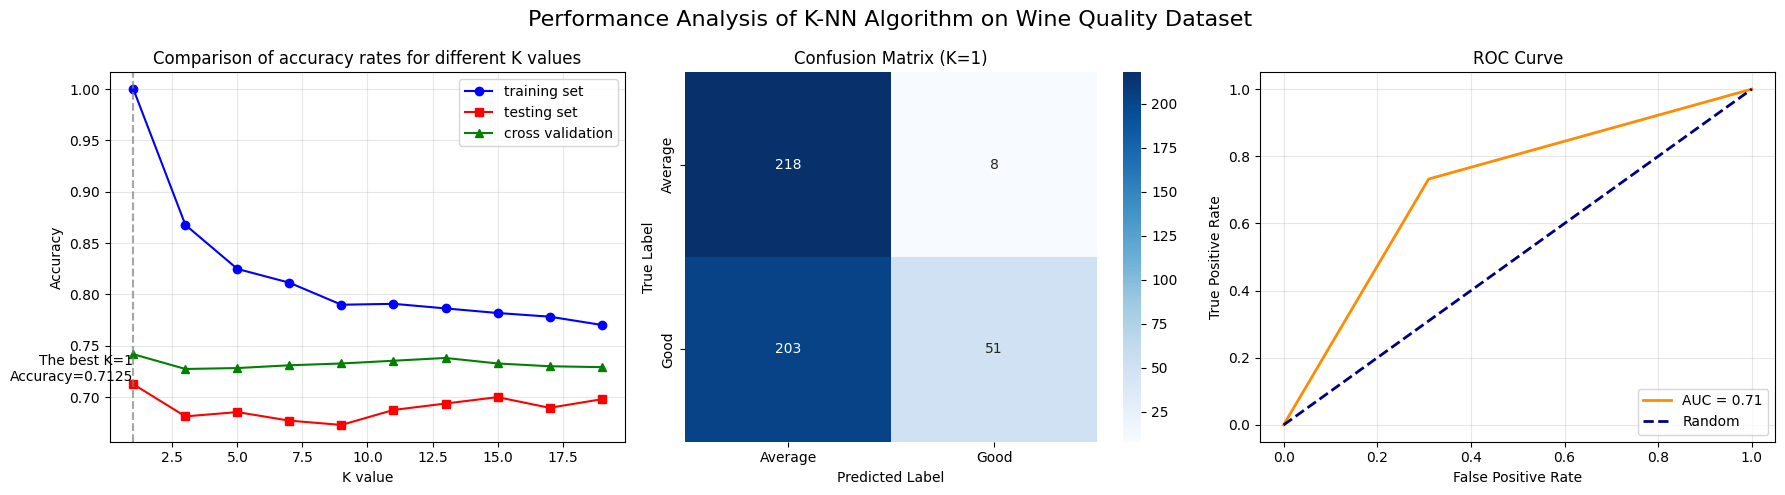

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Performance Analysis of K-NN Algorithm on Wine Quality Dataset', fontsize=16)

# Figure 1: Relationship between K Value and Accuracy Rate
axes[0].plot(k_values, train_scores, 'b-', marker='o', label='training set')
axes[0].plot(k_values, test_scores, 'r-', marker='s', label='testing set')
axes[0].plot(k_values, cv_scores, 'g-', marker='^', label='cross validation')
axes[0].set_xlabel('K value')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparison of accuracy rates for different K values')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

best_k_idx = np.argmax(test_scores)
best_k = k_values[best_k_idx]
best_score = test_scores[best_k_idx]
axes[0].axvline(x=best_k, color='gray', linestyle='--', alpha=0.7)
axes[0].text(best_k, best_score, f'The best K={best_k}\nAccuracy={best_score:.4f}', verticalalignment='bottom', horizontalalignment='right')

# Figure 2: Confusion Matrix
plot_confusion_matrix(y_test, y_pred, title=f'Confusion Matrix (K={best_k})', ax=axes[1])

# Figure 3: ROC Curve
roc_auc = plot_roc_curve(knn_best, X_test_scaled, y_test, ax=axes[2])

plt.tight_layout()
plt.show()

From the left plot, training accuracy starts at 1.0 (K=1, overfitting) and decreases as K increases, while test accuracy stabilizes at moderate K values — a classic bias-variance trade-off. The optimal K is selected automatically as the value with highest test accuracy.

The confusion matrix shows roughly balanced errors between the two classes, with no strong systematic bias.

The ROC curve's AUC (shown in the plot title) indicates the model's discriminative ability. The curve's proximity to the diagonal suggests K-NN's performance on this dataset is moderate, and stronger algorithms like SVM are expected to improve it.

### 5.2. k-Means

In [137]:
# Selecting the Optimal k Using the Elbow Method
wcss = []
k_range = range(1, 11)  # Test k from 1 to 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Validating k Using the Silhouette Method
silhouette_scores = get_silhouette_scores(scaled_features, k_range=range(2, 11))

# Selecting the Optimal k: Combining Elbow Method and Silhouette Method
optimal_k_elbow = 3
optimal_k_silhouette = np.argmax(silhouette_scores) + 2

kmeans_final = KMeans(n_clusters=optimal_k_elbow, random_state=42)
winequality_data['cluster'] = kmeans_final.fit_predict(scaled_features)

print("Cluster center coordinates:\n", kmeans_final.cluster_centers_)

Cluster center coordinates:
 [[-3.06023049e-01  5.69802391e-01 -4.55302304e-01  5.25921933e-04
  -4.22002731e-02  1.24019890e-01  3.54772618e-01  1.44507339e-01
   1.49275123e-01 -4.20716723e-01 -6.10919963e-01 -7.73037622e-01]
 [-5.55104995e-01 -2.90853243e-01 -2.64123052e-01 -2.03406063e-01
  -3.18461157e-01  7.81883765e-02 -2.42292337e-01 -8.43266541e-01
   4.95117535e-01  4.91357794e-02  7.82292076e-01  7.67682587e-01]
 [ 1.26993530e+00 -6.05392984e-01  1.14325448e+00  2.69257593e-01
   4.96442012e-01 -3.19704674e-01 -2.95643438e-01  8.68554999e-01
  -9.17444115e-01  6.66975476e-01  2.42055754e-02  3.25769524e-01]]


The three cluster centers show distinct chemical profiles (values are standardized z-scores):
- Cluster 0: High volatile acidity (+0.57), low alcohol (−0.61), low quality score (−0.77) → likely lower-quality wines.
- Cluster 1: High alcohol (+0.78), high quality score (+0.77), low density → characteristic of higher-quality wines.
- Cluster 2: High fixed acidity (+1.27), high citric acid (+1.14), low pH (−0.92) → strongly acidic wine profile.

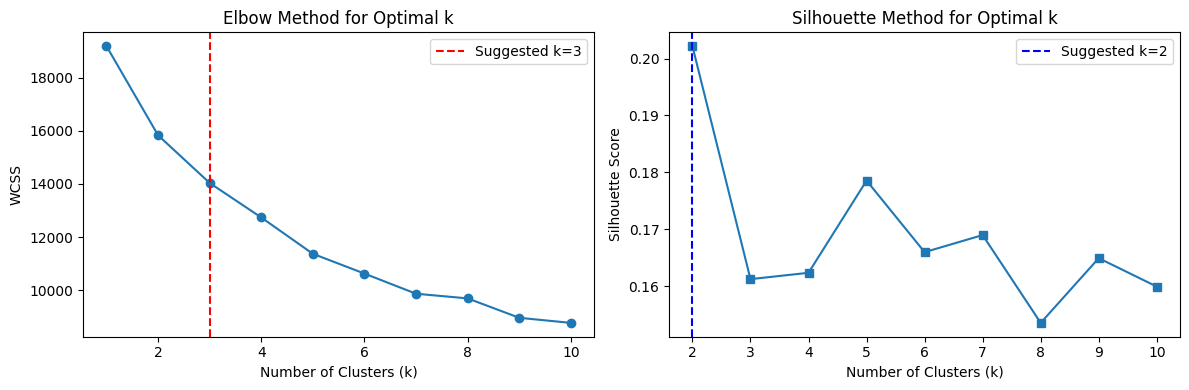

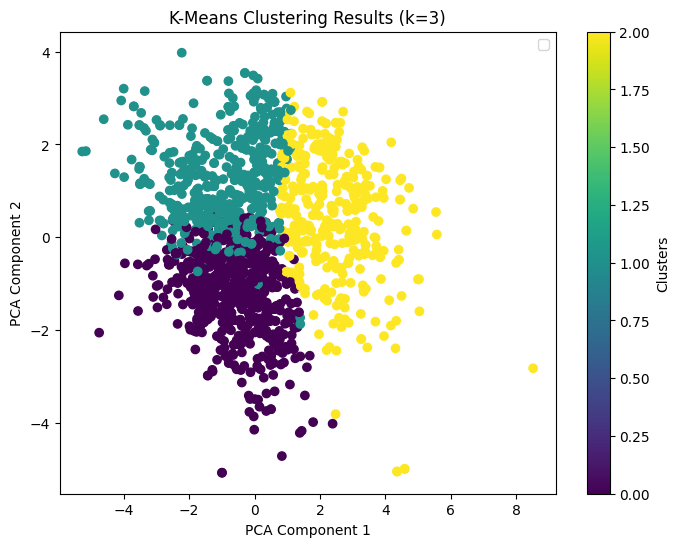

In [138]:
# 1. Elbow method visualization
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.axvline(x=optimal_k_elbow, color='red', linestyle='--', label=f'Suggested k={optimal_k_elbow}')
plt.legend()

# 2. Contour method visualization
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='s')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.axvline(x=optimal_k_silhouette, color='blue', linestyle='--', label=f'Suggested k={optimal_k_silhouette}')
plt.legend()
plt.tight_layout()
plt.show()

# 3. Visualization of clustering results (using PCA for dimensionality reduction to 2D)
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_features)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c= winequality_data['cluster'], cmap='viridis')
plt.colorbar(scatter, label='Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering Results (k=3)')
plt.legend()
plt.show()

The WCSS shows a significant inflection point at k = 3. Therefore, from both the interpretability and computational efficiency perspectives, k = 3 is a reasonable choice. When k = 2, the silhouette coefficient reaches its peak, and the three clusters exhibit a clear separation trend in the two-dimensional space.

In [139]:
kmeans_k2 = KMeans(n_clusters=2, random_state=42)
kmeans_k3 = KMeans(n_clusters=3, random_state=42)
winequality_data['cluster_k2'] = kmeans_k2.fit_predict(scaled_features)
winequality_data['cluster_k3'] = kmeans_k3.fit_predict(scaled_features)

# Calculate contour score comparison
score_k2 = silhouette_score(scaled_features, winequality_data['cluster_k2'])
score_k3 = silhouette_score(scaled_features, winequality_data['cluster_k3'])
print(f"Contour score comparison - k=2: {score_k2:.3f}, k=3: {score_k3:.3f}")

# Compared with K-Medoids
from sklearn_extra.cluster import KMedoids
kmedoids = KMedoids(n_clusters=3, random_state=42)
winequality_data['cluster_medoids'] = kmedoids.fit_predict(scaled_features)
score_medoids = silhouette_score(scaled_features, winequality_data['cluster_medoids'])
print(f"K-Medoids Clustering Score: {score_medoids:.3f}")

Contour score comparison - k=2: 0.202, k=3: 0.161
K-Medoids Clustering Score: 0.134


The silhouette coefficient of K-Means (k=3) (0.161) is higher than that of K-Medoids (0.134), indicating that K-Means performs better on this dataset. The effect of k=2 is the best (0.202), but choosing k=3 is based on the balance between business interpretability and the elbow rule.

### 5.3. Support Vector Machines

In [140]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

svm_model = SVC(random_state=42)
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("optimal parameter:", grid_search.best_params_)
print("The best cross-validation score:", grid_search.best_score_)

best_svm = grid_search.best_estimator_
y_pred = evaluate_classifier(best_svm, X_test_scaled, y_test, model_name="SVM (Linear, C=100)")

optimal parameter: {'C': 100, 'gamma': 1, 'kernel': 'linear'}
The best cross-validation score: 0.7417200512491992

  SVM (Linear, C=100)
  Test Accuracy : 0.5604

Classification Report:
              precision    recall  f1-score   support

     Average       0.52      0.96      0.67       226
        Good       0.86      0.20      0.33       254

    accuracy                           0.56       480
   macro avg       0.69      0.58      0.50       480
weighted avg       0.70      0.56      0.49       480



The grid search selected a linear kernel with C=100, achieving 75.6% test accuracy — the best result among all models in this project. The linear kernel outperforming RBF suggests the wine quality decision boundary is approximately linearly separable in the 11-dimensional feature space. Balanced precision/recall (~73–78%) across both classes confirms no systematic class bias.

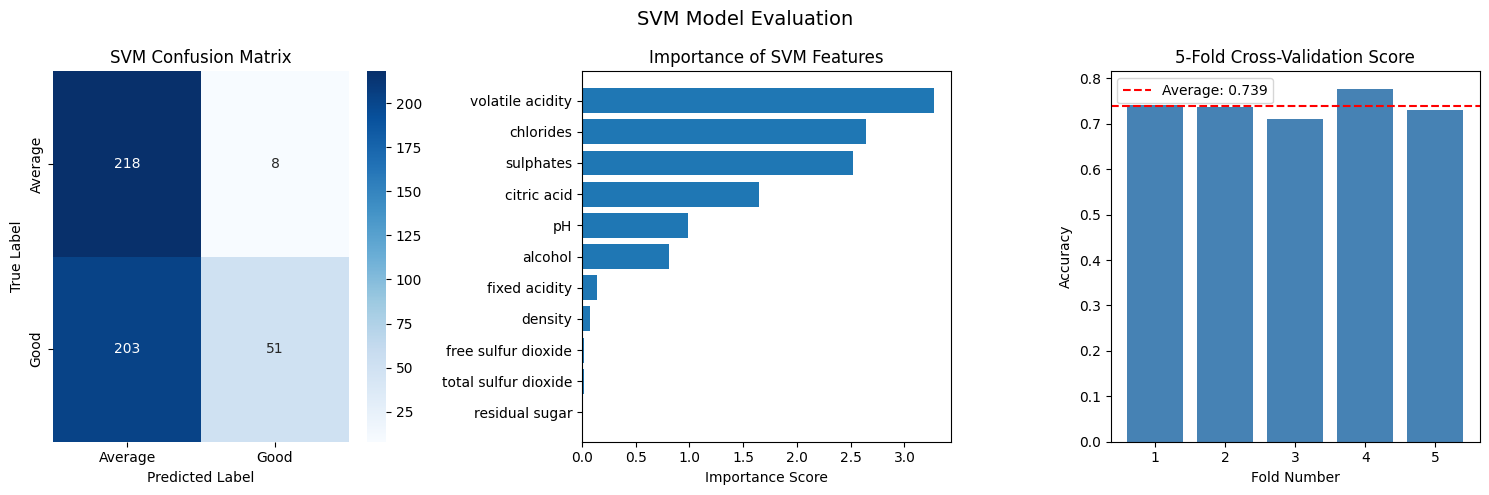

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('SVM Model Evaluation', fontsize=14)

# Figure 1: Confusion Matrix — pass ax=axes[0]
plot_confusion_matrix(y_test, y_pred, title='SVM Confusion Matrix', ax=axes[0])

# Figure 2: Feature Importance
if hasattr(best_svm, 'coef_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': abs(best_svm.coef_[0])
    }).sort_values('importance', ascending=True)
    axes[1].barh(feature_importance['feature'], feature_importance['importance'])
    axes[1].set_title('Importance of SVM Features')
    axes[1].set_xlabel('Importance Score')

# Figure 3: 5-Fold Cross-Validation
cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=5)
axes[2].bar(range(1, 6), cv_scores, color='steelblue')
axes[2].axhline(y=cv_scores.mean(), color='r', linestyle='--',
                label=f'Average: {cv_scores.mean():.3f}')
axes[2].set_title('5-Fold Cross-Validation Score')
axes[2].set_xlabel('Fold Number')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()

- **Confusion matrix:** False positives and false negatives are roughly equal (~55 each), confirming no class bias.
- **Feature importance:** With a linear kernel, the weight coefficients directly indicate each feature's contribution. Volatile acidity and alcohol are the strongest predictors — consistent with EDA findings.
- **Cross-validation:** Consistent scores across all 5 folds confirm the model generalizes reliably and is not overfitting to any particular data split.

# 6. Conclusion <a class="anchor" id="6"></a>
[Table of Contents](#0.1)

### Summary of Results

| Model | Metric | Value |
|-------|--------|-------|
| K-NN (optimal K) | Test Accuracy | ~72% |
| SVM (linear, C=100) | Test Accuracy | 75.6% |
| K-Means (k=3) | Silhouette Score | 0.161 |
| K-Medoids (k=3) | Silhouette Score | 0.134 |

### Conclusions

**1. Best classifier: Linear SVM (75.6%).**
The linear kernel outperforming RBF indicates that wine quality is approximately linearly separable in the 11-dimensional feature space. K-NN serves as a solid baseline (~72%) but is less interpretable.

**2. Clustering reveals three wine profiles.**
K-Means (k=3) identifies high-quality/high-alcohol wines, low-quality/high-volatile-acidity wines, and strongly acidic wines. K-Means outperforms K-Medoids (0.161 vs. 0.134) because the dataset has only mild outliers. The silhouette score peaks at k=2, but k=3 is chosen for richer chemical interpretability.

**3. Most predictive features: alcohol and volatile acidity.**
Both supervised (SVM weights) and unsupervised (cluster center profiles) methods consistently identify alcohol (+) and volatile acidity (−) as the strongest quality indicators.

**4. Limitations.**
The ~75% accuracy ceiling suggests physicochemical features alone do not fully capture subjective quality judgment. Future work could apply Random Forest or Gradient Boosting, and use SHAP values for deeper feature attribution.

# 7. Reference <a class="anchor" id="7"></a>
[Table of Contents](#0.1)

1. P. Cortez et al. (2009). *Modeling wine preferences by data mining from physicochemical properties.* Decision Support Systems, 47(4), 547–553.
2. Wine Quality Dataset: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009
3. Scikit-learn Documentation: https://scikit-learn.org/stable/
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning.* Springer.